In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('updated_dataset.csv')


In [5]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,2061,3,...,3,3,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,2062,4,...,3,1,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2064,2,...,4,2,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,2065,4,...,3,4,0,17,3,2,9,6,0,8


In [6]:
## Dependent and Independent Features

x = df.drop('Attrition' , axis=1)
y = df['Attrition']

In [7]:
## Train test split
from sklearn.model_selection import train_test_split

x_train , x_test , y_train ,y_test = train_test_split(x,y, test_size=0.25 , random_state=1)

x_train.shape , x_test.shape

((1102, 31), (368, 31))

In [8]:
num_features = x.select_dtypes(exclude='object').columns.to_list()
print(f'no of numerical columns : {len(num_features)}')
print(num_features)

no of numerical columns : 24
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [9]:
cat_features = x.select_dtypes(include='object').columns.to_list()
print(f'no of categorical columns : {len(cat_features)}')
print(cat_features)

no of categorical columns : 7
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [10]:
## Encoding and standardization
from sklearn.preprocessing import StandardScaler , OrdinalEncoder , LabelEncoder
from sklearn.compose import ColumnTransformer 

oe = OrdinalEncoder()
scaler = StandardScaler()

preprocessor = ColumnTransformer(
    [
        ('OrdinalEncoder' , oe , cat_features) , 
        ('StandardScaler' , scaler , num_features)
    ] , remainder='passthrough'
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OrdinalEncoder', ...), ('StandardScaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transforme

In [11]:
x_train = preprocessor.fit_transform(x_train)
x_test = preprocessor.transform(x_test)

In [12]:
## Encoding the target column 
le = LabelEncoder()
y_train= le.fit_transform(y_train)  # Converts 'No'/'Yes' to 0/1
y_test= le.transform(y_test)


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report , roc_auc_score

models = {
    'Logistic Regression' : LogisticRegression(n_jobs=-1) ,
    'Support Vector Classifier' : SVC() ,
    'Gaussian NB' : GaussianNB() , 
    'KNN Classifier' : KNeighborsClassifier(n_jobs=-1) ,
    'Decision Tree Classifier' : DecisionTreeClassifier() , 
    'Random Forest Classifier' : RandomForestClassifier(n_jobs=-1) ,
    'AdaBoost Classifier' : AdaBoostClassifier() ,
    'Gradient Boosting classifier' : GradientBoostingClassifier() , 
    'XGBoost Classifier' : XGBClassifier()
}

for name, model in models.items():
    ## Model Training
    print(f"\n---------- Training Model : {name} ----------  \n")
    model.fit(x_train, y_train)

    # Make predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    
    print('Model performance for Training set')
    print(classification_report(y_train , y_train_pred))
    print('- Roc Auc Score: {:.4f}'.format(roc_auc_score(y_train , y_train_pred)))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print(classification_report(y_test , y_test_pred))
    print('- Roc Auc Score: {:.4f}'.format(roc_auc_score(y_test , y_test_pred)))
    
    print('\n')
    print('='*35)
    print('\n')



---------- Training Model : Logistic Regression ----------  

Model performance for Training set
              precision    recall  f1-score   support

           0       0.90      0.98      0.93       933
           1       0.76      0.37      0.49       169

    accuracy                           0.88      1102
   macro avg       0.83      0.67      0.71      1102
weighted avg       0.87      0.88      0.87      1102

- Roc Auc Score: 0.6727
----------------------------------
Model performance for Test set
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       300
           1       0.78      0.31      0.44        68

    accuracy                           0.86       368
   macro avg       0.82      0.64      0.68       368
weighted avg       0.85      0.86      0.83       368

- Roc Auc Score: 0.6444





---------- Training Model : Support Vector Classifier ----------  

Model performance for Training set
              precision   

In [14]:
lr_params = {
    'penalty' : ['l1', 'l2', 'elasticnet'] ,
    'C' : [10 , 1 , 0.1 , 0.01] ,
    'solver' : ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga'] ,
    'class_weight' : ['balanced']
}

svc_params = {
    'C' : [100 , 10 , 1 , 0.1 , 0.01] , 
    'gamma' : [10 , 1 , 0.1 , 0.01 , 0.001],
    'kernel' : ['linear', 'rbf', 'sigmoid'] , 
    'class_weight' : ['balanced']
}

knn_params = {
    'algorithm' : ['auto', 'ball_tree', 'kd_tree', 'brute'] ,
    'weights' : ['uniform', 'distance'] 
}

dt_params = {
    'criterion' : ['gini', 'entropy', 'log_loss'] ,
    'splitter' : ['best', 'random'] , 
    'max_depth' : [1,2,3,4,5] ,
    'max_features' : ['auto', 'sqrt', 'log2'] ,
    'class_weight' : ['balanced']
}

rf_params = {
    "max_depth": [5, 8, 15, None, 10],
    "max_features": [5, 7, "auto", 8],
    "min_samples_split": [2, 8, 15, 20],
    "n_estimators": [100, 200, 500, 1000] ,
    'class_weight' : ['balanced']
}

ada_params = {
    'n_estimators' : [20,40,50,60,70,80,90,100]
}

gb_params = {
    'loss' : ['log_loss', 'deviance', 'exponential'] ,
    'criterion' : ['friedman_mse', 'squared_error'] ,
    'max_features' : ['auto', 'sqrt', 'log2'] ,
    'n_estimators' : [20,40,50,60,70,80,90,100]
}
xgb_params = {
    "learning_rate": [0.1, 0.01],
    "max_depth": [5, 8, 12, 20, 30],
    "n_estimators": [100, 200, 300],
    "colsample_bytree": [0.5, 0.8, 1, 0.3, 0.4] ,
    'scale_pos_weight' : [np.sum(y_train == 0) / np.sum(y_train == 1)]
}

In [15]:
# Models list for Hyperparameter tuning
randomcv_models = [
    ("Logistic Regression" , models['Logistic Regression'] , lr_params) , 
    ("Support Vector Classifier" , models['Support Vector Classifier'] , svc_params) ,
    ("KNN Classifier" , models['KNN Classifier'] , knn_params) ,
    ("Decision Tree Classifier" , models['Decision Tree Classifier'] , dt_params),
    ("Random Forest Classifier" , models['Random Forest Classifier'] , rf_params) ,
    ("AdaBoost Classifier" , models['AdaBoost Classifier'] , ada_params) ,
    ("Gradient Boosting classifier" , models['Gradient Boosting classifier'] , gb_params) ,
    ("XGBoost Classifier" , models['XGBoost Classifier'] , xgb_params)
]

In [16]:
from sklearn.model_selection import RandomizedSearchCV

model_params = {}

for name,model,params in randomcv_models:
    random = RandomizedSearchCV(estimator=model , param_distributions=params , n_iter=100 , cv=3 , verbose=2 , n_jobs=-1)
    random.fit(x_train,y_train)

    model_params[name] = random.best_params_

Fitting 3 folds for each of 60 candidates, totalling 180 fits
[CV] END C=10, class_weight=balanced, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END C=10, class_weight=balanced, penalty=l1, solver=sag; total time=   0.0s
[CV] END C=10, class_weight=balanced, penalty=l1, solver=lbfgs; total time=   0.0s
[CV] END C=10, class_weight=balanced, penalty=l1, solver=newton-cg; total time=   0.0s
[CV] END C=10, class_weight=balanced, penalty=l1, solver=newton-cg; total time=   0.0s
[CV] END C=10, class_weight=balanced, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END C=10, class_weight=balanced, penalty=l1, solver=newton-cg; total time=   0.0s
[CV] END C=10, class_weight=balanced, penalty=l1, solver=sag; total time=   0.0s
[CV] END C=10, class_weight=balanced, penalty=l1, solver=lbfgs; total time=   0.0s
[CV] END C=10, class_weight=balanced, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END C=10, class_weight=balanced, penalty=l1, solver=sag; total time=   0.0s
[CV] EN

In [17]:
for model_name in model_params:
    print(f"---------------- Best Params for Model : {model_name} -------------------")
    print(model_params[model_name])

---------------- Best Params for Model : Logistic Regression -------------------
{'solver': 'lbfgs', 'penalty': 'l2', 'class_weight': 'balanced', 'C': 0.1}
---------------- Best Params for Model : Support Vector Classifier -------------------
{'kernel': 'rbf', 'gamma': 0.1, 'class_weight': 'balanced', 'C': 100}
---------------- Best Params for Model : KNN Classifier -------------------
{'weights': 'uniform', 'algorithm': 'auto'}
---------------- Best Params for Model : Decision Tree Classifier -------------------
{'splitter': 'random', 'max_features': 'log2', 'max_depth': 3, 'criterion': 'log_loss', 'class_weight': 'balanced'}
---------------- Best Params for Model : Random Forest Classifier -------------------
{'n_estimators': 100, 'min_samples_split': 2, 'max_features': 5, 'max_depth': None, 'class_weight': 'balanced'}
---------------- Best Params for Model : AdaBoost Classifier -------------------
{'n_estimators': 40}
---------------- Best Params for Model : Gradient Boosting classi

In [18]:
optimized_models = {
    'Logistic Regression' : LogisticRegression(**model_params['Logistic Regression'], n_jobs=-1) ,
    'Support Vector Classifier' : SVC(**model_params['Support Vector Classifier']) ,
    'Gaussian Naive Bayes' : GaussianNB() ,
    'KNN Classifier' : KNeighborsClassifier(**model_params['KNN Classifier'], n_jobs=-1) ,
    'Decision Tree Classifier' : DecisionTreeClassifier(**model_params['Decision Tree Classifier']) ,
    'Random Forest Classifier' : RandomForestClassifier(**model_params['Random Forest Classifier'], n_jobs=-1) , 
    'AdaBoost Classifier' : AdaBoostClassifier(**model_params['AdaBoost Classifier']) ,
    'Gradient Boosting classifier' : GradientBoostingClassifier(**model_params['Gradient Boosting classifier']) ,
    'XGBoost Classifier' : XGBClassifier(**model_params['XGBoost Classifier']) ,
}

for name, model in optimized_models.items():
    ## Model Training
    print(f"\n---------- Training Model : {name} ----------  \n")
    model.fit(x_train, y_train)

    # Make predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    
    print('Model performance for Training set')
    print(classification_report(y_train , y_train_pred))
    print('- Roc Auc Score: {:.4f}'.format(roc_auc_score(y_train , y_train_pred)))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print(classification_report(y_test , y_test_pred))
    print('- Roc Auc Score: {:.4f}'.format(roc_auc_score(y_test , y_test_pred)))
    
    print('\n')
    print('='*35)
    print('\n')



---------- Training Model : Logistic Regression ----------  

Model performance for Training set
              precision    recall  f1-score   support

           0       0.95      0.75      0.84       933
           1       0.36      0.78      0.49       169

    accuracy                           0.75      1102
   macro avg       0.65      0.76      0.66      1102
weighted avg       0.86      0.75      0.78      1102

- Roc Auc Score: 0.7627
----------------------------------
Model performance for Test set
              precision    recall  f1-score   support

           0       0.93      0.71      0.81       300
           1       0.37      0.75      0.50        68

    accuracy                           0.72       368
   macro avg       0.65      0.73      0.65       368
weighted avg       0.82      0.72      0.75       368

- Roc Auc Score: 0.7317





---------- Training Model : Support Vector Classifier ----------  

Model performance for Training set
              precision   

In [19]:


# Add the models to the list that you want to view on the ROC plot
auc_models = [
    {
        'label': 'Logistic Regression',
        'model': optimized_models['Logistic Regression'],
        'auc':  0.7317
    },
    {
        'label': 'Gaussian Naive Bayes',
        'model': optimized_models['Gaussian Naive Bayes'],
        'auc':  0.7248
    },
    {
        'label': 'KNN Classifier',
        'model': optimized_models['KNN Classifier'],
        'auc':  0.5448
    },
    {
        'label': 'Decision Tree Classifier',
        'model': optimized_models['Decision Tree Classifier'],
        'auc':  0.6093
    },
    {
        'label': 'Random Forest Classifier',
        'model': optimized_models['Random Forest Classifier'],
        'auc':  0.5986
    },
    {
        'label': 'AdaBoost Classifier',
        'model': optimized_models['AdaBoost Classifier'],
        'auc':  0.6110
    },
    {
        'label' : 'Gradient Boosting classifier' ,
        'model' : optimized_models['Gradient Boosting classifier'] ,
        'auc' : 0.6321
    },
    {
        'label' : 'XGBoost Classifier' ,
        'model' : optimized_models['XGBoost Classifier'] ,
        'auc' : 0.6628
    },
]

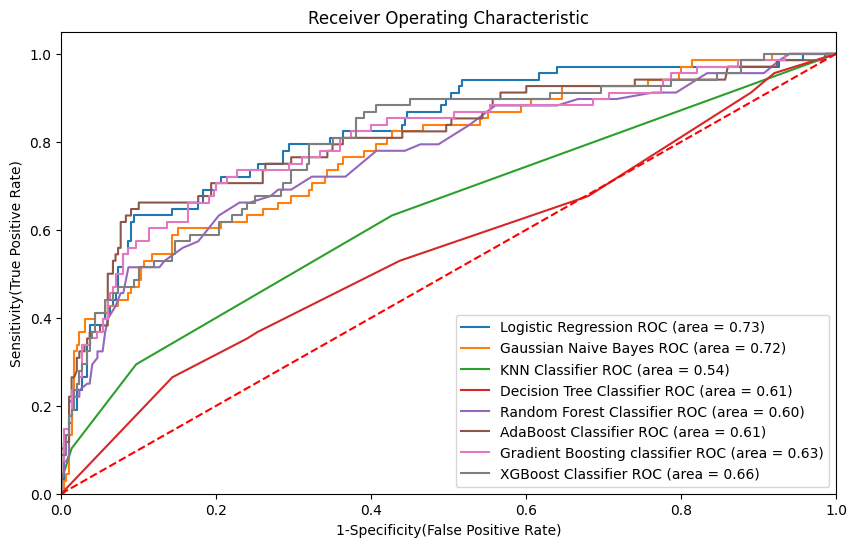

In [20]:
## Plot ROC AUC Curve
from sklearn.metrics import roc_auc_score,roc_curve
plt.figure(figsize=(10,6))

# create loop through all model
for algo in auc_models:
    model = algo['model'] # select the model
    model.fit(x_train, y_train) # train the model

    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(x_test)[:,1])  # Compute False postive rate, and True positive rate

    plt.plot(fpr, tpr, label='%s ROC (area = %0.2f)' % (algo['label'], algo['auc']))    # Calculate Area under the curve to display on the plot

# Custom settings for the plot 
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show() 

In [21]:
## Based on f1-score , recall , roc_auc_score -> best model Logistic Regression (with class weight balancing)

import pickle
pickle.dump(optimized_models['Logistic Regression'] , open('/Users/dhruvitjalodhara/programming/ML Practice/Employee Attrition Prediction/Models/model.pkl' , 'wb'))
pickle.dump(preprocessor , open('/Users/dhruvitjalodhara/programming/ML Practice/Employee Attrition Prediction/Models/preprocessor.pkl' , 'wb'))
